# Mathematical intuition behind Adaboost

## Create a Sample Dataset

In [ ]:
#!pip install mlxtend

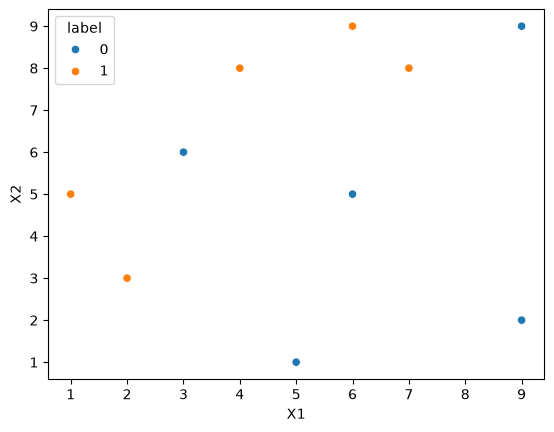

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Create a simple dataset
df = pd.DataFrame()
df['X1'] = [1, 2, 3, 4, 5, 6, 6, 7, 9, 9]
df['X2'] = [5, 3, 6, 8, 1, 9, 5, 8, 9, 2]
df['label'] = [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]

# Plot the dataset
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])
plt.show()

## Step 1: Initialize Weights

In [ ]:
df['weights'] = 1 / df.shape[0]

## Step 2: Train the First Weak Learner

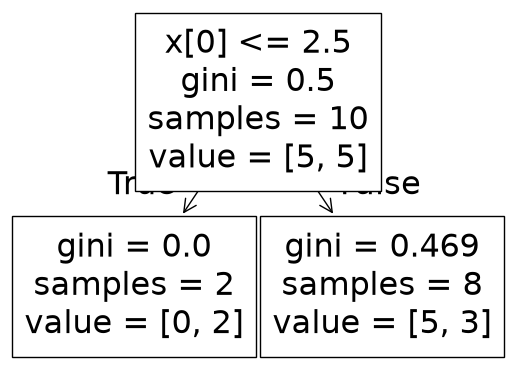

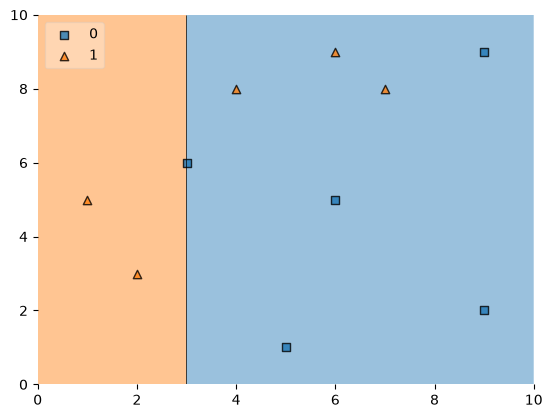

In [ ]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

dt1 = DecisionTreeClassifier(max_depth=1)
dt1.fit(X, y)

plot_tree(dt1)
plt.show()

plot_decision_regions(X, y, clf=dt1, legend=2)
plt.show()

df['y_pred'] = dt1.predict(X)

## Step 3: Calculate Model Weight (Alpha)


In [ ]:
def calculate_model_weight(error):
    return 0.5 * np.log((1 - error) / error)

error1 = 0.3
alpha1 = calculate_model_weight(error1)
alpha1

np.float64(0.42364893019360184)

## Step 4: Update Weights


In [ ]:
def update_row_weights(row, alpha):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

df['updated_weights'] = df.apply(update_row_weights, alpha=alpha1, axis=1)
df

df['normalized_weights'] = df['updated_weights'] / df['updated_weights'].sum()

## Step 5: Create a New Dataset


In [ ]:
def create_new_dataset(df):
    indices = []
    for i in range(df.shape[0]):
        a = np.random.random()
        for index, row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']
index_values = create_new_dataset(df)
new_df = df.iloc[index_values, [0, 1, 2, 3]]
new_df

,X1,X2,label,weights
4,5,1,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1
3,4,8,1,0.1
5,6,9,1,0.1
7,7,8,1,0.1
2,3,6,0,0.1
9,9,2,0,0.1
3,4,8,1,0.1
5,6,9,1,0.1


## Step 6: Train the Second Weak Learner

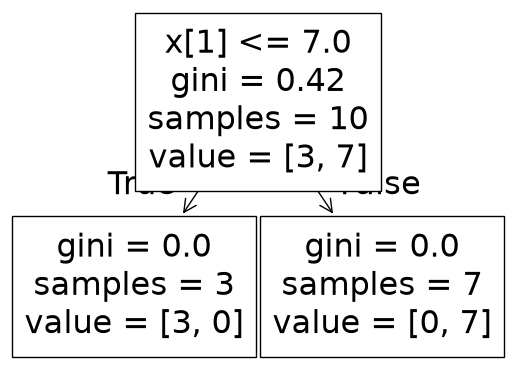

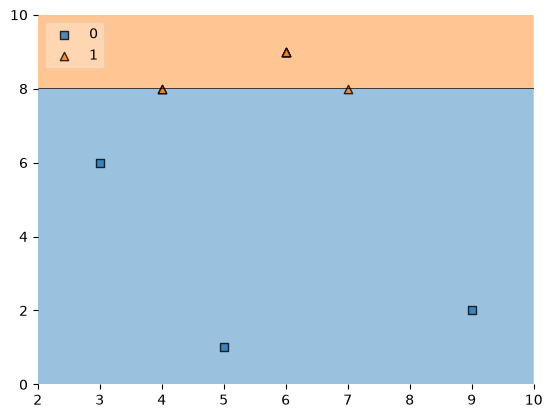

np.float64(1.0986122886681098)

In [ ]:
X_new = new_df.iloc[:, 0:2].values
y_new = new_df.iloc[:, 2].values

dt2 = DecisionTreeClassifier(max_depth=1)
dt2.fit(X_new, y_new)

plot_tree(dt2)
plt.show()

plot_decision_regions(X_new, y_new, clf=dt2, legend=2)
plt.show()

new_df['y_pred'] = dt2.predict(X_new)
new_df

error2 = 0.1
alpha2 = calculate_model_weight(error2)
alpha2

## Step 7: Update Weights Again


In [ ]:
new_df['updated_weights'] = new_df.apply(update_row_weights, alpha=alpha2, axis=1)

new_df['normalized_weights'] = new_df['updated_weights'] / new_df['updated_weights'].sum()
new_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
4,5,1,0,0.1,0,0.033333,0.1
5,6,9,1,0.1,1,0.033333,0.1
5,6,9,1,0.1,1,0.033333,0.1
3,4,8,1,0.1,1,0.033333,0.1
5,6,9,1,0.1,1,0.033333,0.1
7,7,8,1,0.1,1,0.033333,0.1
2,3,6,0,0.1,0,0.033333,0.1
9,9,2,0,0.1,0,0.033333,0.1
3,4,8,1,0.1,1,0.033333,0.1
5,6,9,1,0.1,1,0.033333,0.1


## Step 8: Train the Third-Weak Learner


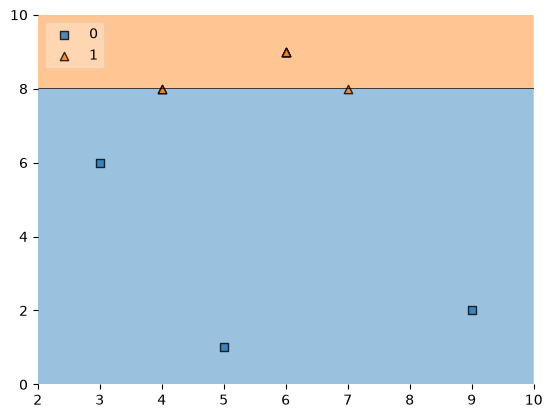

np.float64(-0.4236489301936017)

In [ ]:
X_new = new_df.iloc[:, 0:2].values
y_new = new_df.iloc[:, 2].values

dt3 = DecisionTreeClassifier(max_depth=1)
dt3.fit(X_new, y_new)

plot_decision_regions(X_new, y_new, clf=dt3, legend=2)
plt.show()

new_df['y_pred'] = dt3.predict(X_new)
new_df

error3 = 0.7
alpha3 = calculate_model_weight(error3)
alpha3

## Final Strong Classifier


In [ ]:
def final_prediction(query, classifiers, alphas):
    predictions = np.array([clf.predict(query) for clf in classifiers])
    final_score = np.dot(alphas, predictions)
    return np.sign(final_score)

classifiers = [dt1, dt2, dt3]
alphas = [alpha1, alpha2, alpha3]

query1 = np.array([1, 5]).reshape(1, -1)
query2 = np.array([9, 9]).reshape(1, -1)

print(final_prediction(query1, classifiers, alphas))
print(final_prediction(query2, classifiers, alphas))

[1.]
[1.]


# Sklearn Adaboost


## 1. Creating the Dataset

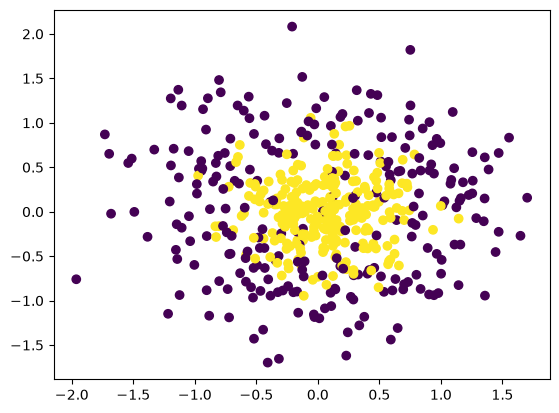

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles


np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

## 2. Training the AdaBoost Classifier


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

model = AdaBoostClassifier()
accuracy = np.mean(cross_val_score(model, X, y, scoring='accuracy', cv=10))
print(f"Cross-Validation Accuracy: {accuracy}")

model.fit(X, y)

Cross-Validation Accuracy: 0.812


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.39,0.41,0.38,...,0.48,0.48,0.48]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[0.44,0.34,0.47,...,0.1 ,0.09,0.1 ]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1264648382), DecisionTreeC...te=1312958716), DecisionTreeC...te=1653982164), DecisionTreeC...ate=819956639), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](2,)","[0.54,0.46]"


## 3. Visualizing the Decision Boundary


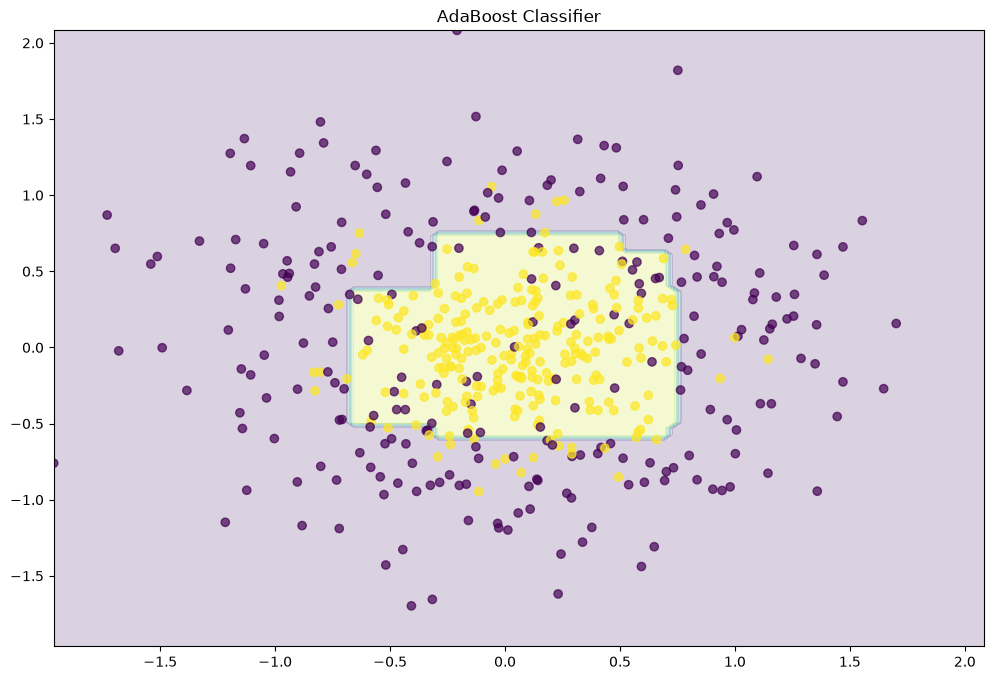

In [ ]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12, 8))
    x_range = np.linspace(X.min(), X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
    y_hat = y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
    plt.title("AdaBoost Classifier")
    plt.show()

plot_decision_boundary(model)

## Hyperparameter Tuning


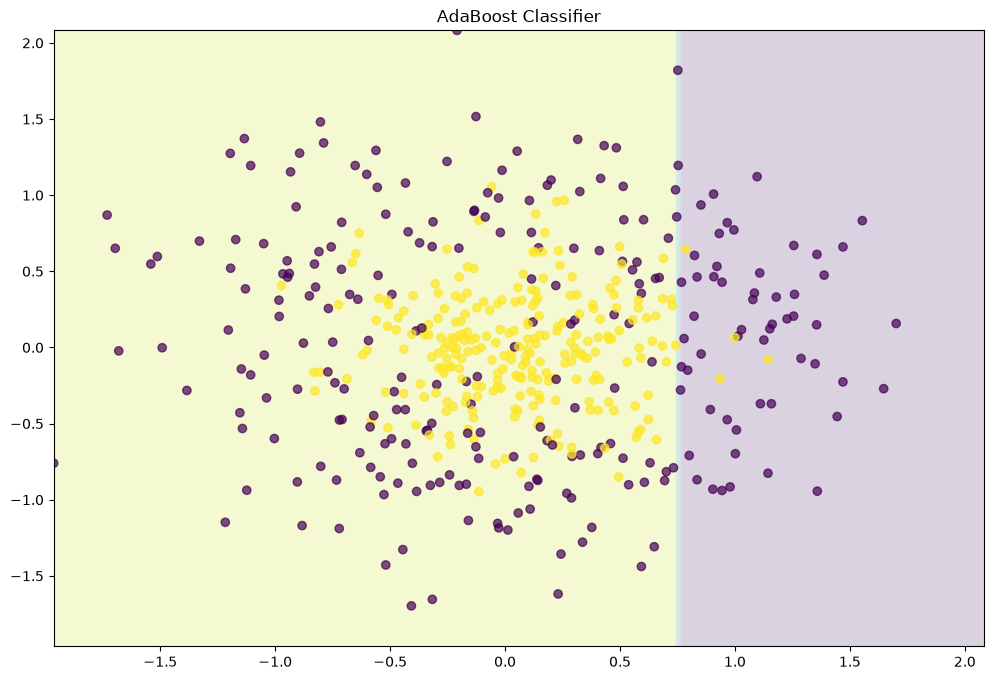

Cross-Validation Accuracy: 0.5660000000000001


In [ ]:
model = AdaBoostClassifier(n_estimators=1)
model.fit(X, y)
plot_decision_boundary(model)
accuracy = np.mean(cross_val_score(model, X, y, scoring='accuracy', cv=10))
print(f"Cross-Validation Accuracy: {accuracy}")

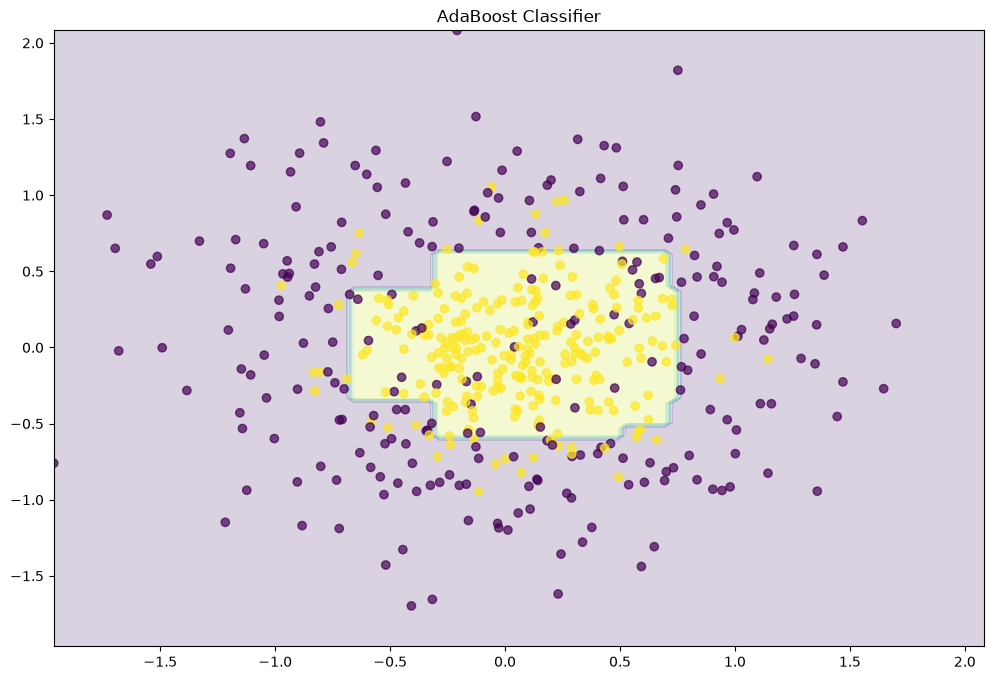

Cross-Validation Accuracy: 0.8140000000000001


In [ ]:
model = AdaBoostClassifier(n_estimators=100)
model.fit(X, y)
plot_decision_boundary(model)
accuracy = np.mean(cross_val_score(model, X, y, scoring='accuracy', cv=10))
print(f"Cross-Validation Accuracy: {accuracy}")

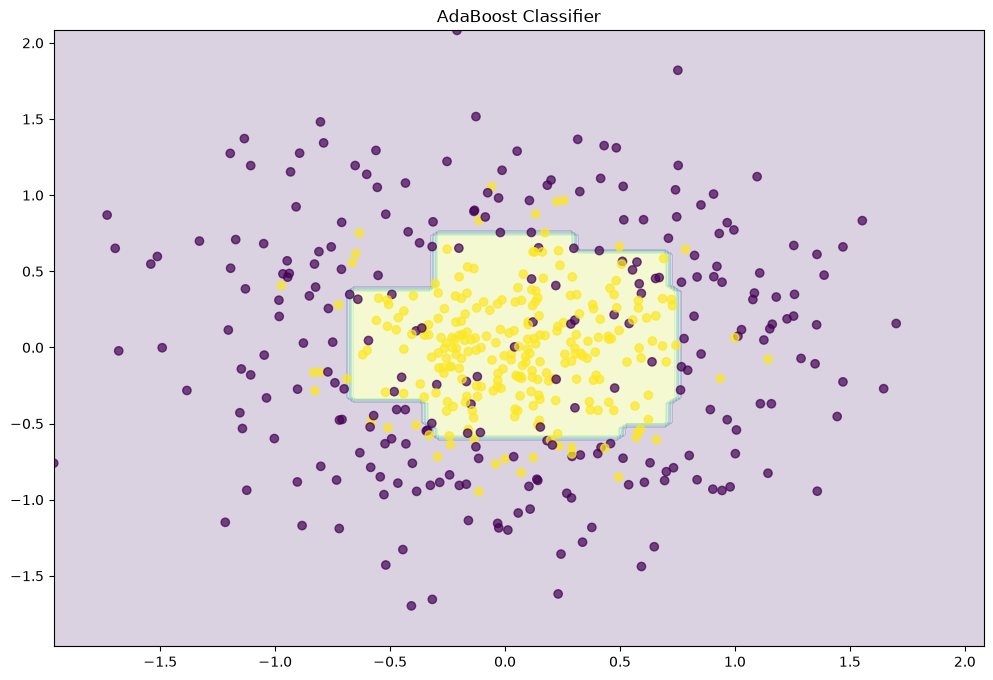

Cross-Validation Accuracy: 0.818


In [ ]:
model = AdaBoostClassifier(n_estimators=125)
model.fit(X, y)
plot_decision_boundary(model)
accuracy = np.mean(cross_val_score(model, X, y, scoring='accuracy', cv=10))
print(f"Cross-Validation Accuracy: {accuracy}")

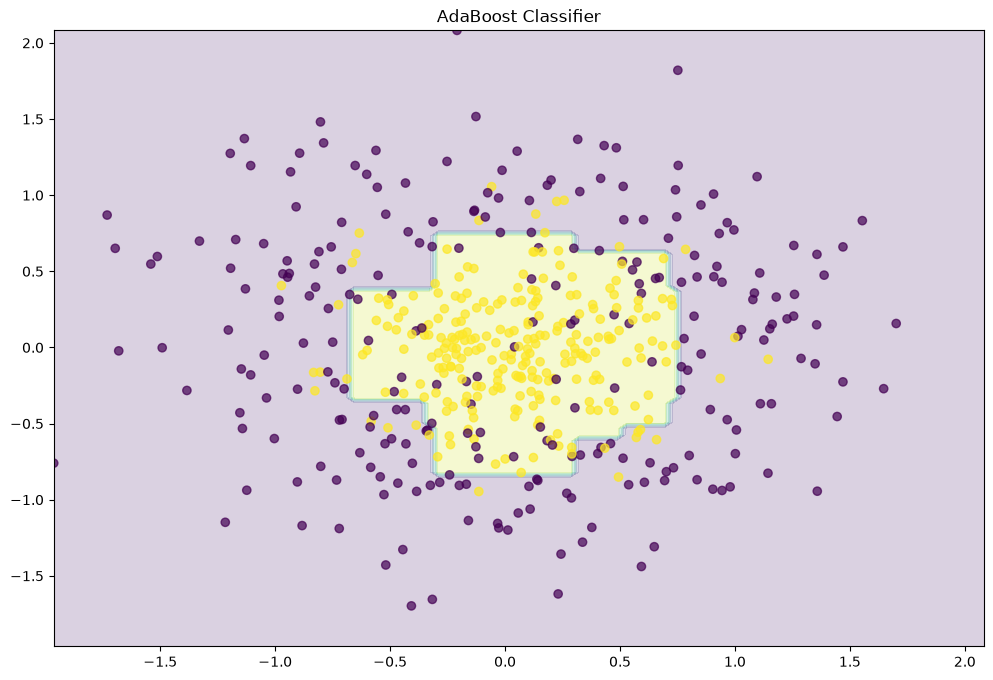

Cross-Validation Accuracy: 0.812


In [ ]:
model = AdaBoostClassifier(n_estimators=200)
model.fit(X, y)
plot_decision_boundary(model)
accuracy = np.mean(cross_val_score(model, X, y, scoring='accuracy', cv=10))
print(f"Cross-Validation Accuracy: {accuracy}")

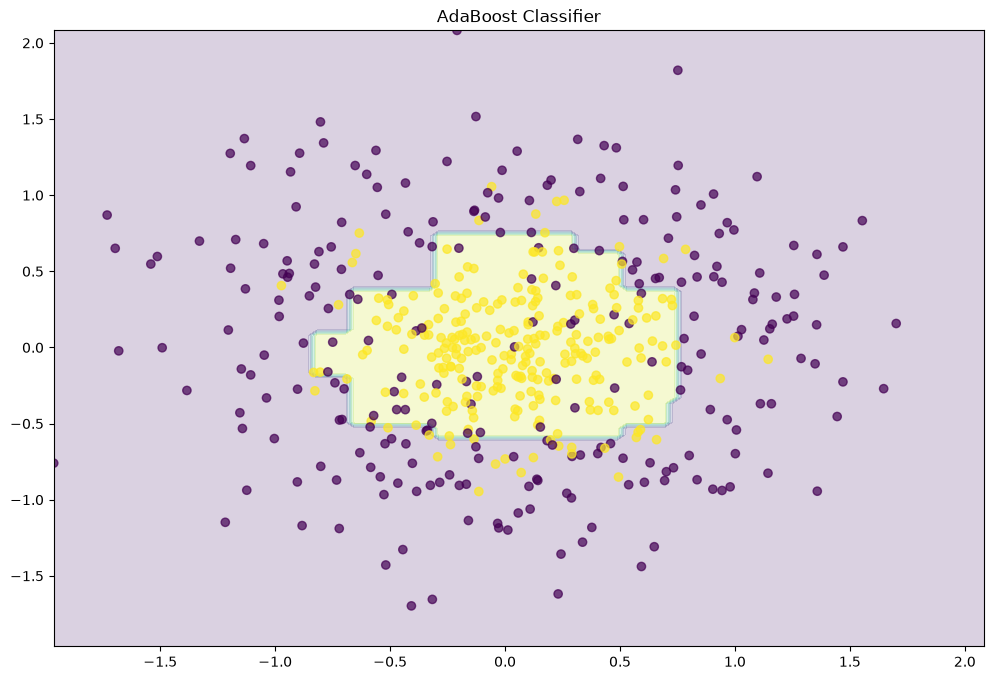

Cross-Validation Accuracy: 0.8099999999999999


In [ ]:
model = AdaBoostClassifier(n_estimators=300)
model.fit(X, y)
plot_decision_boundary(model)
accuracy = np.mean(cross_val_score(model, X, y, scoring='accuracy', cv=10))
print(f"Cross-Validation Accuracy: {accuracy}")

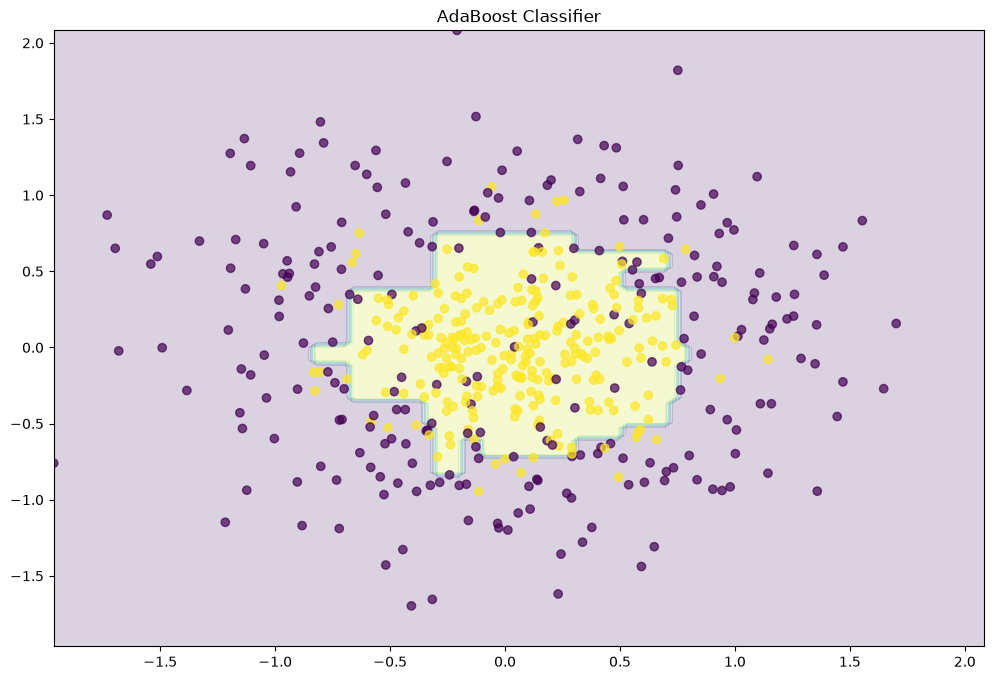

In [ ]:
model = AdaBoostClassifier(n_estimators=1500)
model.fit(X, y)
plot_decision_boundary(model)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

grid = {
    'n_estimators': [300, 350, 400, 450, 500, 550, 600],
    'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5, 1.0]
}

grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(),
    param_grid=grid,
    n_jobs=-1,
    cv=10,
    scoring='accuracy'
)

grid_result = grid_search.fit(X, y)

print(f"Best: {grid_result.best_score_} using {grid_result.best_params_}")

Best: 0.8320000000000001 using {'learning_rate': 0.1, 'n_estimators': 450}


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

grid = {
    'n_estimators': [300, 400, 450, 460, 470, 475, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3]
}

grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(),
    param_grid=grid,
    n_jobs=-1,
    cv=10,
    scoring='accuracy'
)

grid_result = grid_search.fit(X, y)

print(f"Best: {grid_result.best_score_} using {grid_result.best_params_}")

Best: 0.834 using {'learning_rate': 0.15, 'n_estimators': 450}
